### Conecta o google colab ao google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Realiza scraping da página de estatísticas do comércio exterior  
Dados de Importação e Exportação

In [ ]:
# instala as bibliotecas de web scraping - https://pypi.org/
!pip install requests
!pip install beautifulsoup4

In [ ]:
# importa uma biblioteca para fazer requisição http (no caso, get)
import requests

# importa uma biblioteca para extrair dados de arquivos html e xml
from bs4 import BeautifulSoup

Exportação

In [ ]:
# faz a requisição do conteúdo html através da url da página
url = 'https://www.gov.br/produtividade-e-comercio-exterior/pt-br/assuntos/comercio-exterior/estatisticas/base-de-dados-bruta'
r = requests.get(url)
soup = BeautifulSoup(r.content, "html.parser")

# procura o link no html da página, extraindo e armazenando ele
link_exportacao = soup.select_one('a[href$="EXP_2022.csv"]')
exportacao = str(link_exportacao['href']) if link_exportacao else ""

# cria e salva o arquivo na pasta do google drive
r = requests.get(exportacao, verify=False)
with open("/content/drive/MyDrive/Colab Notebooks/comex/exportacao.csv", "wb") as file:
    file.write(r.content)

/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1095: InsecureRequestWarning: Unverified HTTPS request is being made to host 'balanca.economia.gov.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Importação

In [ ]:
# faz a requisição do conteúdo html através da url da página
url = 'https://www.gov.br/produtividade-e-comercio-exterior/pt-br/assuntos/comercio-exterior/estatisticas/base-de-dados-bruta'
r = requests.get(url)
soup = BeautifulSoup(r.content, "html.parser")

# procura o link no html da página, extraindo e armazenando ele
link_importacao = soup.select_one('a[href$="IMP_2022.csv"]')
importacao = str(link_importacao['href']) if link_importacao else ""

# cria e salva o arquivo na pasta do google drive
r = requests.get(importacao, verify=False)
with open("/content/drive/MyDrive/Colab Notebooks/comex/importacao.csv", "wb") as file:
    file.write(r.content)

/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1095: InsecureRequestWarning: Unverified HTTPS request is being made to host 'balanca.economia.gov.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Primeiros passos para analisar os dados

In [ ]:
# importa uma biblioteca para interagir com o sistema de arquivos
import os

# acessa a pasta e lista os arquivos
os.listdir("/content/drive/MyDrive/Colab Notebooks/comex/")

['exportacao.csv', 'importacao.csv']

In [ ]:
# importa uma biblioteca para ler e converter os arquivos em dataframes
import pandas as pd

Exportação

In [ ]:
# armazena o dataframe em uma variável, lendo o arquivo csv e definindo um separador de colunas
exportacao = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/comex/exportacao.csv", sep=";")

# cria uma nova coluna para exibir o tipo de carga
exportacao["TP_CARGA"] = "Exportação"

# exibe as 5 primeiras linhas
exportacao.head()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,TP_CARGA
0,2022,6,85045000,11,69,MG,4,817600,2,1399,19576,Exportação
1,2022,4,39219019,10,586,SP,7,917500,3914,3914,12672,Exportação
2,2022,1,44071100,16,249,SC,1,927800,21945,8409167,5177394,Exportação
3,2022,11,84672100,11,521,RS,1,817800,10,25,487,Exportação
4,2022,10,8072000,10,23,RN,4,417901,55356,55356,71511,Exportação


Importação

In [ ]:
# armazena o dataframe em uma variável, lendo o arquivo csv e definindo um separador de colunas
importacao = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/comex/importacao.csv", sep=";")

# cria uma nova coluna para exibir o tipo de carga
importacao["TP_CARGA"] = "Importação"

# exibe as 5 últimas linhas
importacao.tail()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO,TP_CARGA
2023251,2022,1,39173300,10,249,PR,4,917900,0,0,57,10,0,Importação
2023252,2022,8,30066000,10,355,SC,1,927800,4522,4522,267528,5206,1293,Importação
2023253,2022,10,33012919,10,275,RJ,4,817700,0,0,403,89,0,Importação
2023254,2022,12,39071039,10,160,AM,1,227600,73,73,948,99,0,Importação
2023255,2022,11,85049040,10,160,PR,4,917900,43,43,4985,1046,45,Importação


### Unindo os dataframes

In [ ]:
# une os dataframes em um único, empilhando eles
df = pd.concat([exportacao, importacao], ignore_index=True, sort=False)
display(df)

# ignore_index  = ignora o índice original para não sobrepor ou duplicar informações
# sort          = mantém a ordem original das colunas do primeiro dataframe, adicionando as colunas do segundo dataframe após as demais

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,TP_CARGA,VL_FRETE,VL_SEGURO
0,2022,6,85045000,11,69,MG,4,817600,2,1399,19576,Exportação,NaN,NaN
1,2022,4,39219019,10,586,SP,7,917500,3914,3914,12672,Exportação,NaN,NaN
2,2022,1,44071100,16,249,SC,1,927800,21945,8409167,5177394,Exportação,NaN,NaN
3,2022,11,84672100,11,521,RS,1,817800,10,25,487,Exportação,NaN,NaN
4,2022,10,8072000,10,23,RN,4,417901,55356,55356,71511,Exportação,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3519119,2022,1,39173300,10,249,PR,4,917900,0,0,57,Importação,10.0,0.0
3519120,2022,8,30066000,10,355,SC,1,927800,4522,4522,267528,Importação,5206.0,1293.0
3519121,2022,10,33012919,10,275,RJ,4,817700,0,0,403,Importação,89.0,0.0
3519122,2022,12,39071039,10,160,AM,1,227600,73,73,948,Importação,99.0,0.0


### Validações

In [ ]:
# imprime a quantidade de linhas e colunas do dataframe
df.shape

(3519124, 14)

In [ ]:
# imprime os tipos de dados das colunas do dataframe
df.dtypes

CO_ANO          int64
CO_MES          int64
CO_NCM          int64
CO_UNID         int64
CO_PAIS         int64
SG_UF_NCM      object
CO_VIA          int64
CO_URF          int64
QT_ESTAT        int64
KG_LIQUIDO      int64
VL_FOB          int64
TP_CARGA       object
VL_FRETE      float64
VL_SEGURO     float64
dtype: object

In [ ]:
# imprime os tipos de dados das colunas do dataframe, com mais detalhes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3519124 entries, 0 to 3519123
Data columns (total 14 columns):
 #   Column      Dtype  
---  ------      -----  
 0   CO_ANO      int64  
 1   CO_MES      int64  
 2   CO_NCM      int64  
 3   CO_UNID     int64  
 4   CO_PAIS     int64  
 5   SG_UF_NCM   object 
 6   CO_VIA      int64  
 7   CO_URF      int64  
 8   QT_ESTAT    int64  
 9   KG_LIQUIDO  int64  
 10  VL_FOB      int64  
 11  TP_CARGA    object 
 12  VL_FRETE    float64
 13  VL_SEGURO   float64
dtypes: float64(2), int64(10), object(2)
memory usage: 375.9+ MB


In [ ]:
# compara as colunas dos dataframes antes da junção
print(f'As colunas dos dataframes são: \n{", ".join(exportacao.columns)}\n{", ".join(importacao.columns)}')

As colunas dos dataframes são: 
CO_ANO, CO_MES, CO_NCM, CO_UNID, CO_PAIS, SG_UF_NCM, CO_VIA, CO_URF, QT_ESTAT, KG_LIQUIDO, VL_FOB, TP_CARGA
CO_ANO, CO_MES, CO_NCM, CO_UNID, CO_PAIS, SG_UF_NCM, CO_VIA, CO_URF, QT_ESTAT, KG_LIQUIDO, VL_FOB, VL_FRETE, VL_SEGURO, TP_CARGA


In [ ]:
# conta valores nulos e não nulos de uma coluna específica
print(f'Valores nulos no valor do frete: {df["VL_FRETE"].isna().sum()}')
print(f'Valores não nulos no valor do frete: {df["VL_FRETE"].notna().sum()}')

Valores nulos no valor do frete: 1495868
Valores não nulos no valor do frete: 2023256


In [ ]:
# compara a quantidade de linhas dos dataframes
print(f'Exportação: {exportacao.shape[0]}\nImportação: {importacao.shape[0]}')

Exportação: 1495868
Importação: 2023256


In [ ]:
# verifica quais são os valores únicos de uma coluna específica
print(f'Os valores únicos da coluna de estados são: \n{", ".join(df["SG_UF_NCM"].unique())}')

Os valores únicos da coluna de estados são: 
MG, SP, SC, RS, RN, PA, BA, PR, MA, RJ, PE, ES, SE, AM, AP, RR, AL, AC, RO, MT, CE, GO, MS, ND, TO, DF, PB, PI, EX


In [ ]:
# verifica a quantidade de valores únicos de uma coluna específica
print(f'Temos {df["SG_UF_NCM"].nunique()} siglas diferentes de estados.')

Temos 29 siglas diferentes de estados.


In [ ]:
# verifica a quantidade de cargas não realizadas de/para estados brasileiros
print(f'A quantidade de carga não identificada é: {df[df["SG_UF_NCM"] == "ND"].shape[0]}')
print(f'A quantidade de carga para o exterior é: {df[df["SG_UF_NCM"] == "EX"].shape[0]}')

A quantidade de carga não identificada é: 5314
A quantidade de carga para o exterior é: 7


In [ ]:
# armazena e depois exibe que tipo de carga é responsável pelas não identificadas
counts = df[df["SG_UF_NCM"] == "ND"]["TP_CARGA"].value_counts()
for tipo, count in counts.items():
    print(f'{tipo} = {count}')

Exportação = 5314


### Tratamento

In [ ]:
display(df)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,TP_CARGA,VL_FRETE,VL_SEGURO
0,2022,6,85045000,11,69,MG,4,817600,2,1399,19576,Exportação,NaN,NaN
1,2022,4,39219019,10,586,SP,7,917500,3914,3914,12672,Exportação,NaN,NaN
2,2022,1,44071100,16,249,SC,1,927800,21945,8409167,5177394,Exportação,NaN,NaN
3,2022,11,84672100,11,521,RS,1,817800,10,25,487,Exportação,NaN,NaN
4,2022,10,8072000,10,23,RN,4,417901,55356,55356,71511,Exportação,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3519119,2022,1,39173300,10,249,PR,4,917900,0,0,57,Importação,10.0,0.0
3519120,2022,8,30066000,10,355,SC,1,927800,4522,4522,267528,Importação,5206.0,1293.0
3519121,2022,10,33012919,10,275,RJ,4,817700,0,0,403,Importação,89.0,0.0
3519122,2022,12,39071039,10,160,AM,1,227600,73,73,948,Importação,99.0,0.0


In [ ]:
# mostra as colunas do dataframe
df.columns

Index(['CO_ANO', 'CO_MES', 'CO_NCM', 'CO_UNID', 'CO_PAIS', 'SG_UF_NCM',
       'CO_VIA', 'CO_URF', 'QT_ESTAT', 'KG_LIQUIDO', 'VL_FOB', 'TP_CARGA',
       'VL_FRETE', 'VL_SEGURO'],
      dtype='object')

In [ ]:
# cria uma lista as colunas que serão convertidas
cols = ["CO_ANO", "CO_NCM", "CO_UNID", "CO_PAIS", "SG_UF_NCM", "CO_VIA", "CO_URF", "TP_CARGA"]

# itera sobre a lista, convertendo de inteiro para caractere
for col in cols:
    df[col] = df[col].astype(str)

In [ ]:
df.dtypes

CO_ANO         object
CO_MES          int64
CO_NCM         object
CO_UNID        object
CO_PAIS        object
SG_UF_NCM      object
CO_VIA         object
CO_URF         object
QT_ESTAT        int64
KG_LIQUIDO      int64
VL_FOB          int64
TP_CARGA       object
VL_FRETE      float64
VL_SEGURO     float64
dtype: object

### Gráfico 1: Em 2022, o Brasil importou ou exportou mais?

In [ ]:
# mostra os valores únicos da coluna especificada
df["TP_CARGA"].unique()

array(['Exportação', 'Importação'], dtype=object)

In [ ]:
# mostra a quantidade de registros de cada valor
df["TP_CARGA"].value_counts()

Importação    2023256
Exportação    1495868
Name: TP_CARGA, dtype: int64

In [ ]:
# cria variáveis para armazenar a quantidade de valores
cg_importacao, cg_exportacao = df["TP_CARGA"].value_counts()
cg_importacao, cg_exportacao

(2023256, 1495868)

In [ ]:
# mostra a proporção de importacao sobre o total
imp = cg_importacao / df.shape[0] * 100
print(imp)

57.49317159611312


In [ ]:
# mostra a proporção de exportacao sobre o total
exp = cg_exportacao / df.shape[0] * 100
print(exp)

42.50682840388688


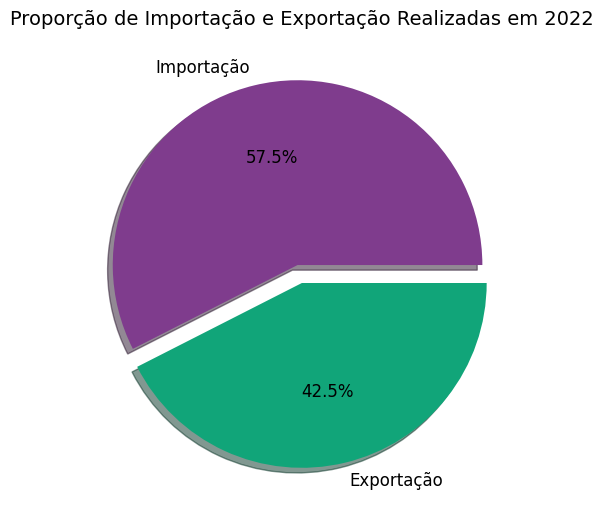

In [ ]:
# importa a biblioteca para plotar o gráfico
import matplotlib.pyplot as plt

# define o tamanho do gráfico
plt.figure(figsize=(10,6))

# define as cores
colors = ["#7F3C8D", "#11A579"]

# define o tipo e personaliza a visualização
plt.pie(
    [imp, exp],
    labels=["Importação", "Exportação"],
    autopct="%.1f%%",
    explode=[0.1, 0],
    textprops = {"fontsize": 12},
    shadow = True,
    colors=colors
)

# personaliza a visualização do título
plt.title(
    "Proporção de Importação e Exportação Realizadas em 2022",
    fontdict = {"size": 14},
    pad=20
)

# exibe o gráfico
plt.show()

In [ ]:
# importa a biblioteca para plotar o gráfico - https://plotly.com/python/
import plotly.express as px

# define os nomes dos eixos e os valores
names = ["Importação", "Exportação"]
values = [imp, exp]

# cria um gráfico de pizza/rosca
fig = px.pie(
    names=names,
    values=values,
    color_discrete_sequence=px.colors.qualitative.Bold
    #, hole=.5
)

# personaliza a visualização
fig.update_layout(
    title_text="Proporção de Importação e Exportação Realizados em 2022",
    title_font=dict(family="Arial", color="black", size=24),
    title_x=0.5,  # Centraliza o título
    font=dict(color="black", size=16)
)

# exibe o gráfico
fig.show()

In [ ]:
# lista de cores para plotly express
colors = px.colors.qualitative.swatches()
colors.show()

### Gráfico 2: Quais os estados que mais exportaram no Brasil em 2022?

In [ ]:
# cria um dataframe que filtra o tipo de carga
df_exportacao = df[df["TP_CARGA"] == "Exportação"]

# agrupa os dados por estado, ordenando pelo valor decrescente
df_exportacao = df_exportacao\
    .groupby("SG_UF_NCM")["VL_FOB"].sum()\
    .sort_values(ascending=False)\
    .head(10).reset_index()

In [ ]:
# importa a biblioteca para plotar o gráfico - https://plotly.com/python/
import plotly.express as px

# cria uma gráfico de barras verticais
fig = px.bar(
    df_exportacao,
    x="SG_UF_NCM",
    y="VL_FOB",
    color="SG_UF_NCM",
    color_discrete_sequence=px.colors.qualitative.Bold
)

# personaliza a visualização
fig.update_layout(
    title_text="Top 10 - Valor FOB de Exportação por Estado em 2022",
    title_font=dict(family="Arial", color="black", size=24),
    title_x=0.5,  # Centraliza o título
    font=dict(color="black", size=16),
    xaxis_title="",  # Remover rótulo do eixo x
    yaxis_title="",   # Remover rótulo do eixo y
    showlegend=False
)

# exibe o gráfico
fig.show()

### Gráfico 3: De que países o Brasil mais importou em 2022?



In [ ]:
# cria um dataframe que filtra o tipo de carga
df_importacao = df[df["TP_CARGA"] == "Importação"]

# agrupa os dados por país, ordenando pelo valor decrescente
df_importacao = df_importacao.groupby("CO_PAIS")["VL_FOB"].sum()\
    .sort_values(ascending=False)\
    .head(5).reset_index()

# imprime os códigos dos países
print(df_importacao)

  CO_PAIS       VL_FOB
0     160  60743964876
1     249  51304351542
2      63  13099925718
3      23  12807743944
4     361   8850184730


In [ ]:
# cria um dicionário que relaciona os códigos com os nomes dos países
paises = {
    "160": "China",
    "249": "Estados Unidos",
    "63": "Argentina",
    "23": "Alemanha",
    "361": "Índia"
}

# substitui os códigos pelos nomes dos países no dataframe
df_importacao["CO_PAIS"] = df_importacao["CO_PAIS"].replace(paises)

In [ ]:
# importa a biblioteca para plotar o gráfico
import plotly.express as px

# cria o gráfico de barras horizontais
fig = px.bar(
    df_importacao,
    x="VL_FOB",
    y="CO_PAIS",
    orientation="h",
    color="CO_PAIS",
    color_discrete_sequence=px.colors.qualitative.Bold
)

# personaliza o gráfico
fig.update_layout(
    title_text="Top 5 - Valor FOB de Importação por País em 2022",
    title_font=dict(family="Arial", color="black", size=24),
    title_x=0.5,  # Centraliza o título
    font=dict(color="black", size=16),
    xaxis_title="",  # Remover rótulo do eixo x
    yaxis_title="",   # Remover rótulo do eixo y
    showlegend=False
)

# exibe o gráfico
fig.show()

### Gráfico 4: Qual a quantidade mensal das cargas exportadas e importadas em 2022?

In [ ]:
# agrupa os dados por tipo de carga e mês, ordenando pela quantidade
df_quantidade = df\
    .groupby(["TP_CARGA", "CO_MES"])[["QT_ESTAT"]].sum()\
    .reset_index()

In [ ]:
# cria um dicionário que relaciona os números com a abreviação dos meses
meses = {
    1: "jan",
    2: "fev",
    3: "mar",
    4: "abr",
    5: "mai",
    6: "jun",
    7: "jul",
    8: "ago",
    9: "set",
    10: "out",
    11: "nov",
    12: "dez"
}

# substitui os números pelas abreviações dos meses no dataframe
df_quantidade["CO_MES"] = df_quantidade["CO_MES"].replace(meses)

In [ ]:
# importa a biblioteca para plotar o gráfico
import plotly.express as px

# cria um gráfico de barras agrupadas
fig = px.bar(
    df_quantidade, barmode="group",
    x="CO_MES", y="QT_ESTAT",
    color="TP_CARGA", color_discrete_sequence=px.colors.qualitative.Bold,
    category_orders={"CO_MES": list(meses.values())}
)

# personaliza o gráfico
fig.update_layout(
    title_text="Quantidade mensal por tipo de carga",
    title_font=dict(family="Arial", color="black", size=24),
    title_x=0.5,  # Centraliza o título
    font=dict(color="black", size=16),
    xaxis_title="",  # Remover rótulo do eixo x
    yaxis_title="",   # Remover rótulo do eixo y
    legend_title_text="Tipo de Carga"
)

# exibe o gráfico
fig.show()

### Gráfico 5: Qual a proporção de frete e seguro nas importações feitas em 2022?

In [ ]:
# instala as bibliotecas para plotar gráficos
!pip install pywaffle

In [ ]:
# armazena a soma dos valores
total_frete = df["VL_FRETE"].sum()
total_seguro = df["VL_SEGURO"].sum()

# armazena o total das variáveis juntas
total = total_frete + total_seguro

# calcula a proporção das variáveis em relação ao total
frete = round((total_frete / total) * 100)
seguro = round((total_seguro / total) * 100)

# define os nomes que serão exibidos para cada variável
data = {"Frete": frete, "Seguro": seguro}

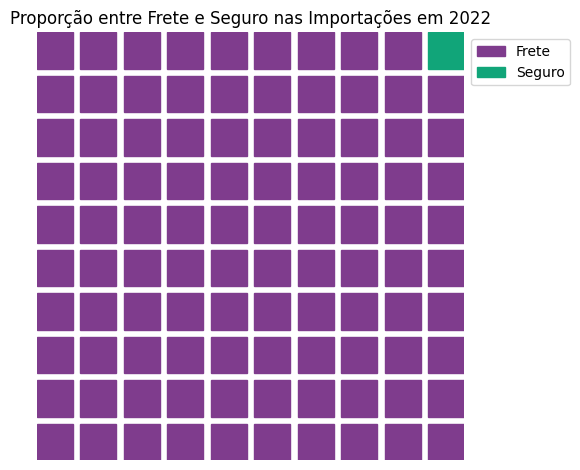

In [ ]:
# importa a biblioteca para plotar o gráfico
import matplotlib.pyplot as plt
from pywaffle import Waffle

# define as cores
colors = ["#7F3C8D", "#11A579"]

# cria um gráfico de waffle
fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    columns=10,
    values=data,
    colors=colors,
    legend={"loc": "upper left", "bbox_to_anchor": (1, 1)},
    font_size=12,
)

# personaliza o título do gráfico
plt.title("Proporção entre Frete e Seguro nas Importações em 2022")

# exibe o gráfico
plt.show()

### Gráfico 6: Qual o peso mensal da carga transportada?

In [ ]:
# agrupa os dados por tipo de carga e mês, ordenando pela peso
df_peso = df\
    .groupby(["TP_CARGA", "CO_MES"])["KG_LIQUIDO"].sum()\
    .reset_index()

In [ ]:
# cria um dicionário que relaciona os números com a abreviação dos meses
meses = {
    1: "jan",
    2: "fev",
    3: "mar",
    4: "abr",
    5: "mai",
    6: "jun",
    7: "jul",
    8: "ago",
    9: "set",
    10: "out",
    11: "nov",
    12: "dez"
}

# substitui os números pelas abreviações dos meses no dataframe
df_peso["CO_MES"] = df_peso["CO_MES"].replace(meses)

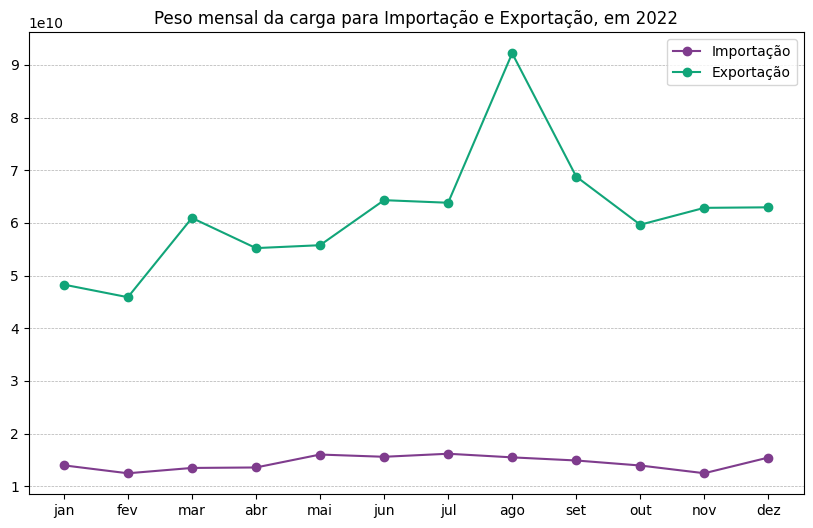

In [ ]:
# importa a biblioteca para plotar o gráfico
import matplotlib.pyplot as plt

# define o tamanho do gráfico
plt.figure(figsize=(10, 6))

# define as cores
colors = ["#7F3C8D", "#11A579"]

# linha para importação
plt.plot(
    df_peso[df_peso["TP_CARGA"] == "Importação"]["CO_MES"],
    df_peso[df_peso["TP_CARGA"] == "Importação"]["KG_LIQUIDO"],
    marker='o',
    label='Importação',
    color=colors[0]
)

# linha para exportação
plt.plot(
    df_peso[df_peso["TP_CARGA"] == "Exportação"]["CO_MES"],
    df_peso[df_peso["TP_CARGA"] == "Exportação"]["KG_LIQUIDO"],
    marker='o',
    label='Exportação',
    color=colors[1]
)

# personaliza a visualização do título
plt.title("Peso mensal da carga para Importação e Exportação, em 2022")

# define a grade posterior do gráfico
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# exibe a legenda
plt.legend()

# exibe o gráfico
plt.show()